In [33]:
%pip install langgraph
%pip install langsmith
%pip install IPython
%pip install langchain_tavily
%pip install langchain-google-genai
%pip install google-genai
%pip install google-generativeai

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from typing import Annotated 
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END 
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


import os
import dotenv
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()


model = ChatGoogleGenerativeAI(model='gemini-3.5-flash')
response = model.invoke("What is the capital of France?")
print(response.content)

model.invoke("What is the weather today bro?")


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


[{'type': 'text', 'text': 'The capital of France is **Paris**.', 'extras': {'signature': 'Et8DCtwDAQw51se0wCGG6Rd4z3qGOGLM28Y+wKQ/REFDe9JtBpDNkBS7cZFwdFu7CRC1svN26SpKMEFcQp5lNK2PbqlPh8JaIqB5TJ3QWUV1UwhFuVAjt3RirRegYD86WK0toFUF8B/nrdfHvqY2yvdaf8UVOJ166J6vXqdjq45v9pbsKGwe8z2gBBxVXdKSStu4EHCjDv+AfewIbdmgFm2GqCfTr1xsklH389k3IaCu50XfP+ylIg/Sw1GY+PMRFVuBxkxG4dqhG7MeET2iKjvPO/3g4g+TbvbP6+OtqrlklSysF0ZZFfRFlcZFY7Xq/R7h1Hqdw6T36Gm4LS38b9g9/ecUNWLdaV0guhaS1OTvh7zV3yCkinEfMakf7sesEjAOaWwBrnEeHnUEH6v9wz2u4ADAQt+OYQjx1xb7//fEayOtNp1qHeqKw/RAOo/2Hll/gkc4Aqyir/U4vwij6T2ikJPVRcRN1c4PwsoFzTNzXPQCN90Im+maEcn7XfDhXn32OlyEFM2E70w0c8pF1eHleFBxh5cYKygHbib9EsqKYaf+mw9SkCpEH+DHxUpA5p59k/IHx5cCUQtFINILlpyE4EvrRY7w67wCI58wF/sfWUO+qpRrp6qewLtXKNtElO0='}}]


AIMessage(content=[{'type': 'text', 'text': 'I\'d love to tell you, bro, but I don\'t have real-time access to live weather data, and I don\'t know where you are in the world! \n\nTo get the exact forecast for your spot right now, your best bet is to check your phone\'s weather app or do a quick Google search for "[your city] weather." \n\nWhere are you checking in from, though? If you tell me your city, I can at least tell you what the *average* weather is usually like there this time of year!', 'extras': {'signature': 'EuoICucIAQw51se33Yc7UhQZn1j00fg4g6QhOTDzmIlH2BH+wh3qcy2HrrVO+1zbXIifY4J4CY8JCOcHf5DSf/3e/t53GKDzVQ72s3owPi4wQGOGIidNUyw/3y5EMiXV2wtmIOG194NvMN+rxHpG71/E3Zytx64cdxXVtsnlNGTPfmbnDCW1jwBZ2wj29hj+0+499K8JuBbwGDJ88w8ewGgj+frYZpNhaU/jP8OJt5MpNm2VkQSSI9IbToVmTtvOcH3XGt1SChkNs+aHKxYdNfo8ijWzEEzFdAcwRO06uxKh3s2JAhY1z3MuOzcipDz4y5ggWpOeqhzdJhYyzwrx84TSIYAbwjR2N1BhvavbQhwKoOuQY7TGU2O2R4EYrr7fZA2Do+EHOSu8plywQy7yJWASciN21ns+uUj+LP81QZaWwabBbpvzviDJT/auElibxDlneLPpNeSILz8JKeJnqHGnu

In [35]:
class State(TypedDict):
    """State of the chatbot conversation. Messages are not replaced but added in the list of the messages."""
    messages: Annotated[list[str], add_messages] #in LangGraph is used to attach reducer functions to state fields. The reducer tells LangGraph how to merge updates from multiple nodes or graph branches.



In [36]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)

tool.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.facebook.com/groups/302915185514582/posts/740821111723985',
   'title': 'What is the capital of France? - Facebook',
   'content': "PARIS it is the capital and largest city of France. Located on the Seine in the country's north, it is a major cultural and political centre of",
   'score': 0.88705814,
   'raw_content': None},
  {'url': 'https://en.wikipedia.org/wiki/Paris',
   'title': 'Paris - Wikipedia',
   'content': "As the capital of France, Paris is the seat of France's national government ; Both houses of the French Parliament ; France's highest courts are located in Paris.",
   'score': 0.8708723,
   'raw_content': None}],
 'response_time': 0.0,
 'request_id': 'de4b5b88-4bb0-4d6c-9172-5bbb7c1d643f'}

In [37]:

def multiply(a: int , b: int ) -> int:
    """Multiplies two numbers.
    
    Args:
        a: The first number.
        b: The second number.
    Returns:
        The product of a and b."""
    
    return a*b

In [38]:
tools = [tool, multiply]

In [39]:
llm_with_tools = model.bind_tools(tools)

Key 'additionalProperties' is not supported in schema, ignoring


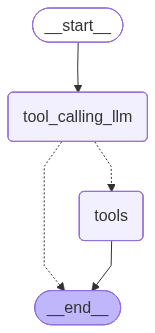

In [40]:
from IPython.display import Image, display

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    
    tools_condition,

)
builder.add_edge("tools", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [41]:
response = graph.invoke({"messages": "What is the recent AI news and please multiply 5 and 3?"})

for m in response['messages']:
    m.pretty_print()




Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported in schema, ignoring
Key 'max_properties' is not supported in schema, ignoring
Key 'min_items' is not supported in schema, ignoring
Key 'min_length' is not supported in schema, ignoring
Key 'min_properties' is not supported in schema, ignoring
Key 'property_ordering' is not supported in schema, ignoring
Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported 

================================ Human Message =================================

What is the recent AI news and please multiply 5 and 3?
================================== Ai Message ==================================

[]
Tool Calls:
  tavily_search (y21u0veh)
 Call ID: y21u0veh
  Args:
    query: latest AI news developments
    topic: news
  multiply (xcq7wgco)
 Call ID: xcq7wgco
  Args:
    b: 3
    a: 5
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news developments", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.axios.com/2026/06/08/ai-news-nvidia-cosmos-3-openai-sites-solara-rtx-spark", "title": "Axios C-Suite: 3 new AI developments for the week of June 6 - Axios", "score": 0.8377398, "published_date": "Mon, 08 Jun 2026 09:57:05 GMT", "content": "# Axios C-Suite: 3 new AI developments for the week of June 6. Fast action AI software:** OpenAI launched Sites, a

# ReAct Agents

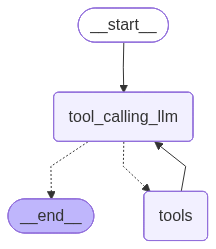

In [42]:
from IPython.display import Image, display

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    
    tools_condition,

)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
response = graph.invoke({"messages": "What is the recent AI news and please multiply 5 and 3?"})

for m in response['messages']:
    m.pretty_print()

Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported in schema, ignoring
Key 'max_properties' is not supported in schema, ignoring
Key 'min_items' is not supported in schema, ignoring
Key 'min_length' is not supported in schema, ignoring
Key 'min_properties' is not supported in schema, ignoring
Key 'property_ordering' is not supported in schema, ignoring
Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported 

# Memory Saver - Checkpoints

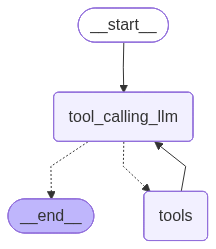

In [ ]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    
    tools_condition,

)
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

piper = builder.compile(checkpointer = memory)

display(Image(piper.get_graph().draw_mermaid_png()))


In [ ]:
config = {"configurable": {"thread_id": "1"}}

piper.invoke({"messages": "Hi My name is Siddhanth."}, config = config)

Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported in schema, ignoring
Key 'max_properties' is not supported in schema, ignoring
Key 'min_items' is not supported in schema, ignoring
Key 'min_length' is not supported in schema, ignoring
Key 'min_properties' is not supported in schema, ignoring
Key 'property_ordering' is not supported in schema, ignoring
Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported 

{'messages': [HumanMessage(content='Hi My name is Siddhanth.', additional_kwargs={}, response_metadata={}, id='86ff09f8-367c-4288-a80d-9d620cc10a1b'),
  AIMessage(content='Hello Siddhanth! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ec406-79f2-7f80-bbca-d0fea1fed62e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1527, 'output_tokens': 12, 'total_tokens': 1539, 'input_token_details': {'cache_read': 0}})]}

In [ ]:
piper.invoke({"messages": "What is my name"}, config = config)

Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported in schema, ignoring
Key 'max_properties' is not supported in schema, ignoring
Key 'min_items' is not supported in schema, ignoring
Key 'min_length' is not supported in schema, ignoring
Key 'min_properties' is not supported in schema, ignoring
Key 'property_ordering' is not supported in schema, ignoring
Key 'additional_properties' is not supported in schema, ignoring
Key 'defs' is not supported in schema, ignoring
Key 'ref' is not supported in schema, ignoring
Key 'any_of' is not supported in schema, ignoring
Key 'example' is not supported in schema, ignoring
Key 'max_items' is not supported in schema, ignoring
Key 'max_length' is not supported 

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 12.837079738s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT